# ⚡ VoltVision — EV Purchase Prediction

This is the **first main notebook** of our VoltVision EV Purchase Prediction project. ⚡

Our goal here is simple: before changing the data or training stronger models, we want to **understand the dataset as it is**. We will inspect the structure, data quality, target balance, feature distributions, relationships with EV purchase, useful interactions, outliers, train/test alignment, and possible leakage.

🎯 **Target:** `Will_Buy_EV`  
`No` → Customer is unlikely to buy an EV  
`Yes` → Customer will buy an EV

For now, this is intentionally an **EDA-only notebook**. We will observe and take notes — encoding, feature creation, preprocessing, and model preparation will happen in the next notebook.

## Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plot_color = sns.color_palette("deep")[0]

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [2]:
test.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (668665, 15)
Test shape: (286571, 14)


Okay, both files are loaded successfully. ✅

The training set contains **668,665 rows and 15 columns**, while the Kaggle test set contains **286,571 rows and 14 columns**. The extra training column is our target, `Will_Buy_EV`.

So this is a **large-row, low-dimensional tabular problem** — a good setting for careful feature analysis and strong tree-based models later.

## Dataset Overview

In [4]:
train.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103211,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


In [7]:
train.describe(include="object").T

,count,unique,top,freq
Gender,668665,3,Male,367954
City_Type,668665,3,Urban,289305
Current_Car_Type,668665,4,Sedan,303459
Home_Charging_Possible,668665,2,Yes,462677
Subsidy_Available,668665,2,Yes,419909
Range_Anxiety_Level,668665,3,Low,603972
Will_Buy_EV,668665,2,No,551886


Nice — the feature space is compact and very interpretable.

We have demographic information (`Age`, `Gender`, `City_Type`), financial information (`Annual_Income_USD`), transport behavior (`Daily_Commute_km`, `Number_of_Cars_Owned`, `Current_Car_Type`), EV infrastructure features, and behavioral/economic signals such as environmental concern, subsidy availability, and range anxiety.

The numeric ranges also look realistic overall: age runs from **25 to 69**, annual income from about **$30k to $188.5k**, and daily commute from **5 km to 98.7 km**.

## Data Quality Check

In [8]:
train_missing = train.isnull().sum()
test_missing = test.isnull().sum()

print("Train missing values:", train_missing.sum())
print("Test missing values:", test_missing.sum())

Train missing values: 0
Test missing values: 0


In [9]:
print("Train duplicate rows:", train.duplicated().sum())
print("Test duplicate rows:", test.duplicated().sum())

Train duplicate rows: 0
Test duplicate rows: 0


In [10]:
categorical_cols = train.drop(columns="Will_Buy_EV").select_dtypes(include="object").columns
numerical_cols = train.drop(columns="Will_Buy_EV").select_dtypes(include=np.number).columns

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

train[categorical_cols].nunique().sort_values()

Numerical columns: 8
Categorical columns: 6


Home_Charging_Possible    2
Subsidy_Available         2
City_Type                 3
Gender                    3
Range_Anxiety_Level       3
Current_Car_Type          4
dtype: int64

Good news — the dataset is already very clean. ✅

There are **0 missing values and 0 exact duplicate rows** in both train and test. The categorical features are also low-cardinality: most have only 2–4 categories.

That means we do **not** need an imputation strategy or rare-category cleanup just to make the data usable. Feature Engineering can stay focused on meaningful transformations instead of repair work.

## Target Variable Analysis

In [11]:
train["Will_Buy_EV"].value_counts()

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

In [12]:
target_percent = train["Will_Buy_EV"].value_counts(normalize=True).mul(100).round(2)
target_percent

Will_Buy_EV
No     82.54
Yes    17.46
Name: proportion, dtype: float64

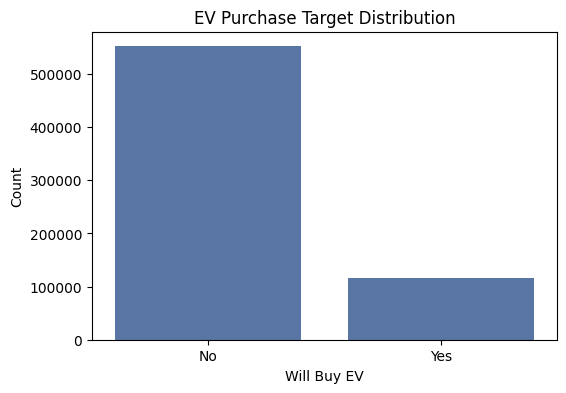

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=train , x="Will_Buy_EV" , color=plot_color)
plt.title("EV Purchase Target Distribution")
plt.xlabel("Will Buy EV")
plt.ylabel("Count")
plt.show()

Ohh, the target is clearly imbalanced. 🎯

About **82.54%** of customers belong to `No`, while only **17.46%** belong to `Yes`.

So accuracy alone will be misleading. A model that predicts `No` for everyone would already look strong by accuracy, even though it would be useless. This confirms why **ROC-AUC should remain our main validation metric**, with Precision, Recall, and F1 used as supporting metrics.

## Numerical Feature Analysis

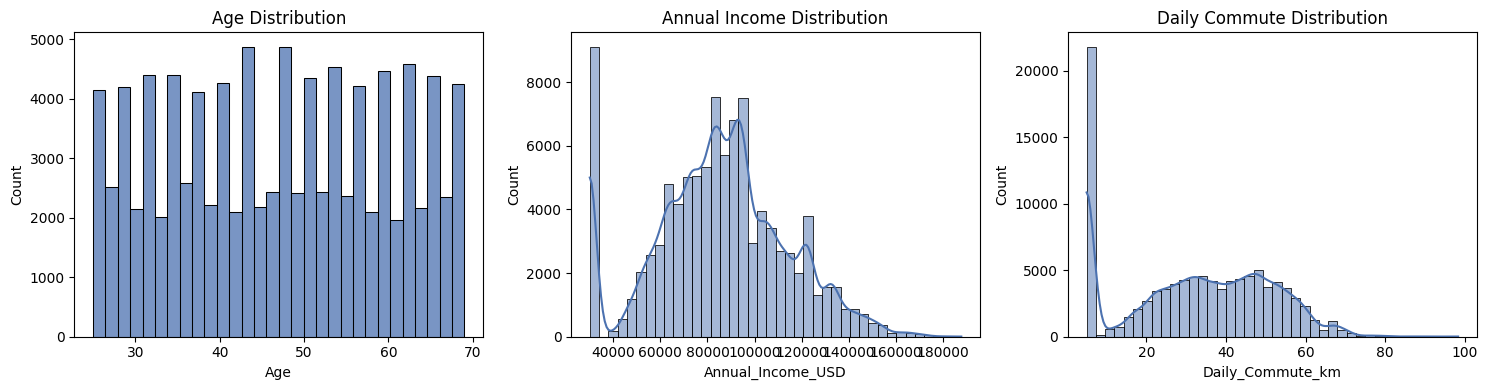

In [14]:
plot_train = train.sample(n=min(100000 , len(train)) , random_state=42)

fig , axes = plt.subplots(1 , 3 , figsize=(15,4))

sns.histplot(data=plot_train , x="Age" , bins=30 , ax=axes[0] , color=plot_color)
sns.histplot(data=plot_train , x="Annual_Income_USD" , bins=40 , kde=True , ax=axes[1] , color=plot_color)
sns.histplot(data=plot_train , x="Daily_Commute_km" , bins=40 , kde=True , ax=axes[2] , color=plot_color)

axes[0].set_title("Age Distribution")
axes[1].set_title("Annual Income Distribution")
axes[2].set_title("Daily Commute Distribution")

plt.tight_layout()
plt.show()

The three main continuous variables look well behaved overall.

`Age` is spread fairly evenly across the allowed range. `Annual_Income_USD` has a broader upper tail, while `Daily_Commute_km` is concentrated more heavily in the lower and middle ranges with fewer very long commuters.

For visualization we used a fixed **100k-row sample** so plotting stays fast, while all statistics in this notebook still use the full dataset.

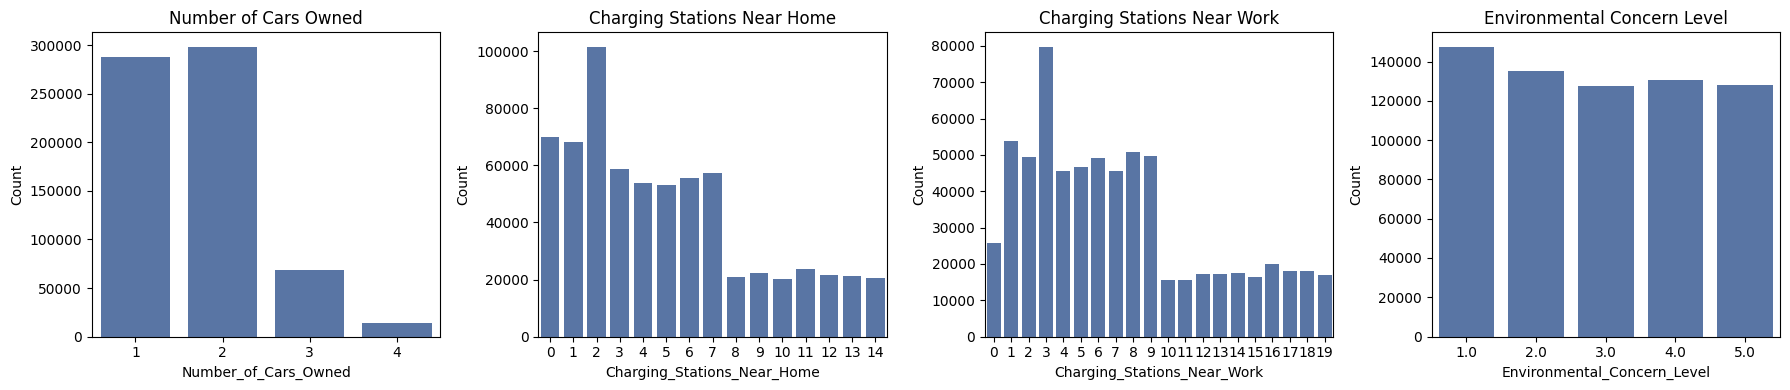

In [15]:
fig , axes = plt.subplots(1 , 4 , figsize=(18,4))

for ax , col in zip(axes , ["Number_of_Cars_Owned" , "Charging_Stations_Near_Home" , "Charging_Stations_Near_Work" , "Environmental_Concern_Level"]):
    counts = train[col].value_counts().sort_index().reset_index()
    counts.columns = [col , "Count"]
    sns.barplot(data=counts , x=col , y="Count" , ax=ax , color=plot_color)
    ax.set_title(col.replace("_" , " "))

plt.tight_layout()
plt.show()

Yeah, the discrete numerical features are also quite structured.

Most customers own **1–2 cars**, environmental concern spans all five levels, and the charging-station counts cover a fairly wide range without looking corrupted.

Nothing here suggests an obvious data-quality problem. We should preserve these values and let the next notebook decide whether any of them deserve grouped or interaction features.

## Categorical Feature Analysis

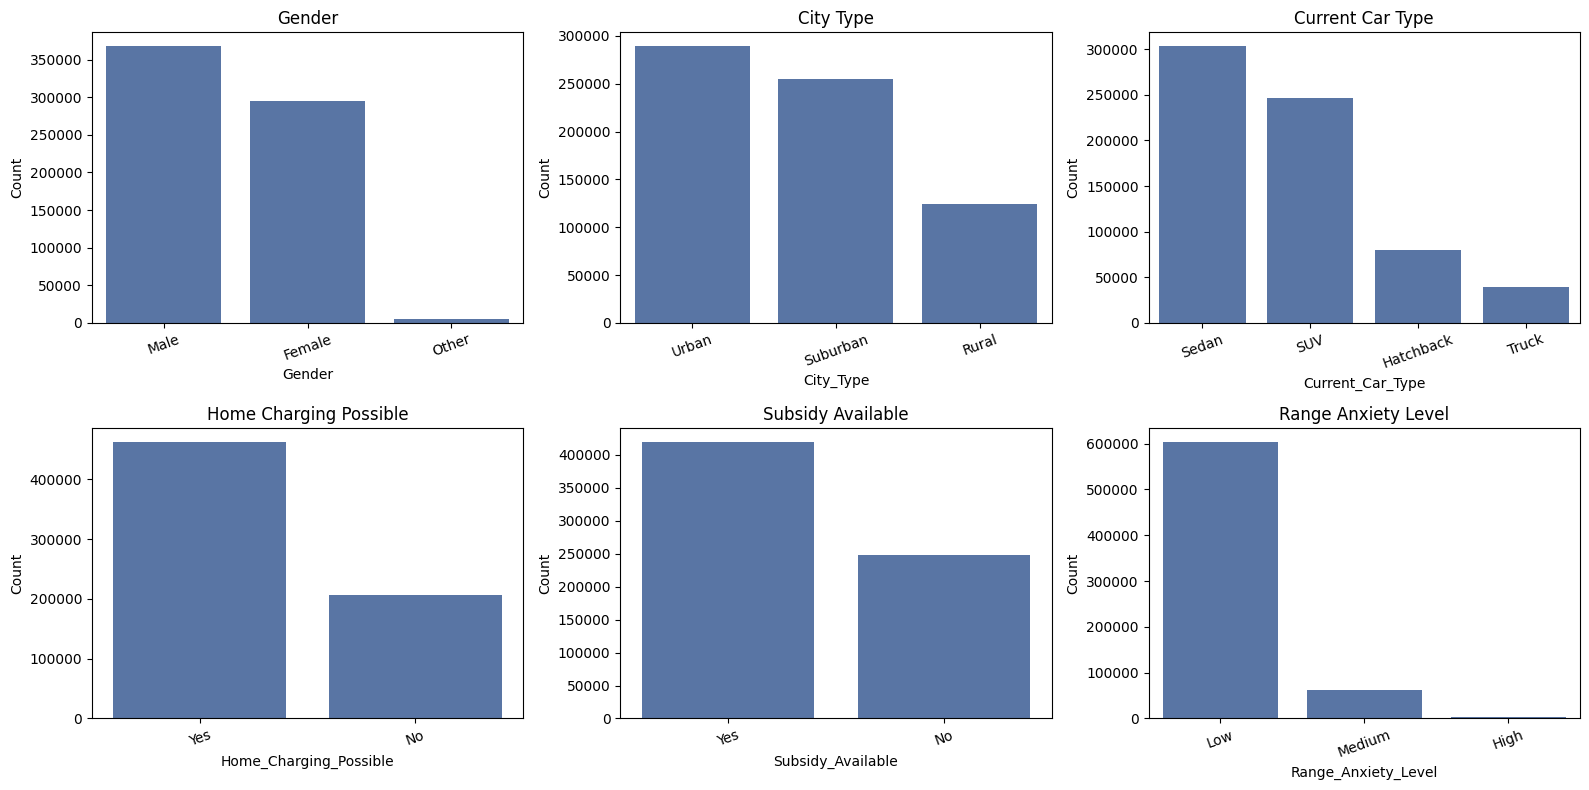

In [16]:
fig , axes = plt.subplots(2 , 3 , figsize=(16,8))
axes = axes.flatten()

for ax , col in zip(axes , categorical_cols):
    counts = train[col].value_counts().reset_index()
    counts.columns = [col , "Count"]
    sns.barplot(data=counts , x=col , y="Count" , ax=ax , color=plot_color)
    ax.set_title(col.replace("_" , " "))
    ax.tick_params(axis="x" , rotation=20)

plt.tight_layout()
plt.show()

Okay, the categorical distributions are uneven but completely manageable.

`Male` is the largest gender group, `Urban` is the most common city type, and Sedan/SUV dominate current car type. Most customers can charge at home, most have a subsidy available, and **Low range anxiety dominates strongly**.

Because every categorical feature has very low cardinality, simple encoding should be enough later — there is no need for aggressive category compression.

## Numerical Features vs EV Purchase

In [17]:
target_numeric = train["Will_Buy_EV"].map({"No":0 , "Yes":1})

numerical_target = train.assign(EV_Buyer=target_numeric).groupby("Will_Buy_EV")[[
    "Age" , "Annual_Income_USD" , "Daily_Commute_km" , "Number_of_Cars_Owned" ,
    "Charging_Stations_Near_Home" , "Charging_Stations_Near_Work" , "Environmental_Concern_Level"
]].mean().round(2)

numerical_target

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
Will_Buy_EV,,,,,,,
No,47.08,81794.59,32.55,1.71,4.99,7.21,2.63
Yes,46.83,98827.30,30.29,1.72,4.82,7.04,4.38


Ohh, now the strongest numerical differences are easy to see.

Customers who buy an EV have average annual income around **$98.8k**, compared with roughly **$81.8k** for non-buyers. Their average environmental concern is also dramatically higher: about **4.38 vs 2.63**.

Daily commute is slightly lower among buyers, while age, car ownership, and raw nearby charging-station counts show much smaller mean differences. So income and environmental concern already look far more important than simple raw infrastructure counts.

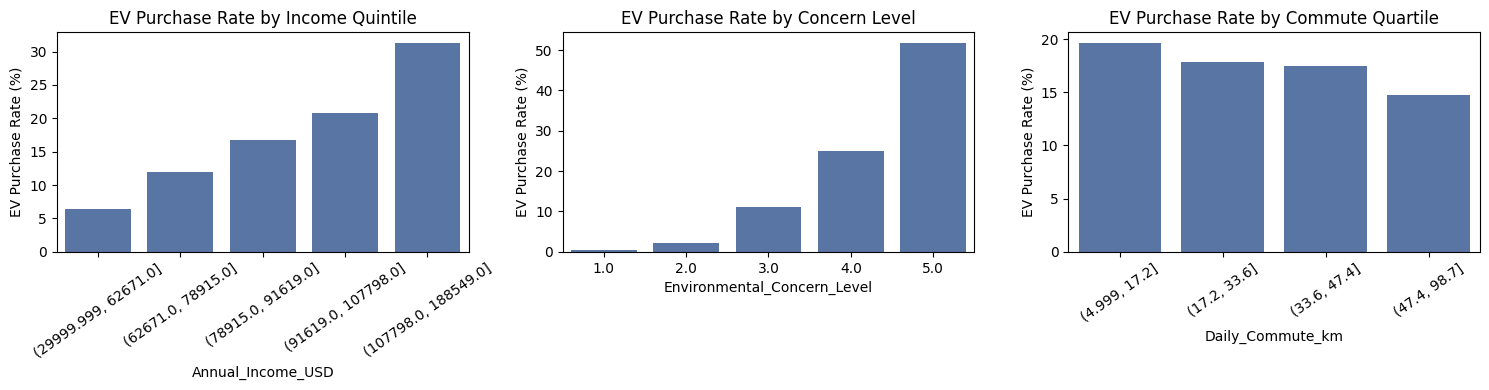

In [18]:
fig , axes = plt.subplots(1 , 3 , figsize=(15,4))

income_bins = pd.qcut(train["Annual_Income_USD"] , q=5 , duplicates="drop")
income_rate = target_numeric.groupby(income_bins , observed=False).mean().mul(100)

concern_rate = target_numeric.groupby(train["Environmental_Concern_Level"]).mean().mul(100)

commute_bins = pd.qcut(train["Daily_Commute_km"] , q=4 , duplicates="drop")
commute_rate = target_numeric.groupby(commute_bins , observed=False).mean().mul(100)

sns.barplot(x=income_rate.index.astype(str) , y=income_rate.values , ax=axes[0] , color=plot_color)
axes[0].set_title("EV Purchase Rate by Income Quintile")
axes[0].tick_params(axis="x" , rotation=35)

sns.barplot(x=concern_rate.index.astype(str) , y=concern_rate.values , ax=axes[1] , color=plot_color)
axes[1].set_title("EV Purchase Rate by Concern Level")

sns.barplot(x=commute_rate.index.astype(str) , y=commute_rate.values , ax=axes[2] , color=plot_color)
axes[2].set_title("EV Purchase Rate by Commute Quartile")
axes[2].tick_params(axis="x" , rotation=35)

for ax in axes:
    ax.set_ylabel("EV Purchase Rate (%)")

plt.tight_layout()
plt.show()

Interesting — these relationships are not subtle.

EV purchase rate rises from about **6.5% in the lowest income quintile to 31.3% in the highest**. Environmental concern is even stronger: Level 1 is below **1%**, while Level 5 reaches about **51.8%**.

Commute shows the opposite direction: customers in the longest-commute group have a lower EV purchase rate. That gives us a good reason to test commute-related interactions later instead of assuming a simple positive effect.

## Categorical Features vs EV Purchase

In [19]:
categorical_rates = {}

for col in categorical_cols:
    rate = pd.crosstab(train[col] , train["Will_Buy_EV"] , normalize="index").mul(100).round(2)
    categorical_rates[col] = rate
    print()
    print(col)
    print(rate)


Gender
Will_Buy_EV     No    Yes
Gender                   
Female       82.24  17.76
Male         82.77  17.23
Other        82.63  17.37

City_Type
Will_Buy_EV     No    Yes
City_Type                
Rural        80.66  19.34
Suburban     81.91  18.09
Urban        83.89  16.11

Current_Car_Type
Will_Buy_EV          No    Yes
Current_Car_Type              
Hatchback         82.57  17.43
SUV               81.90  18.10
Sedan             82.80  17.20
Truck             84.36  15.64

Home_Charging_Possible
Will_Buy_EV                No    Yes
Home_Charging_Possible              
No                      87.29  12.71
Yes                     80.42  19.58

Subsidy_Available
Will_Buy_EV           No    Yes
Subsidy_Available              
No                 99.42   0.58
Yes                72.53  27.47

Range_Anxiety_Level
Will_Buy_EV             No    Yes
Range_Anxiety_Level              
High                 99.86   0.14
Low                  81.10  18.90
Medium               95.83   4.17


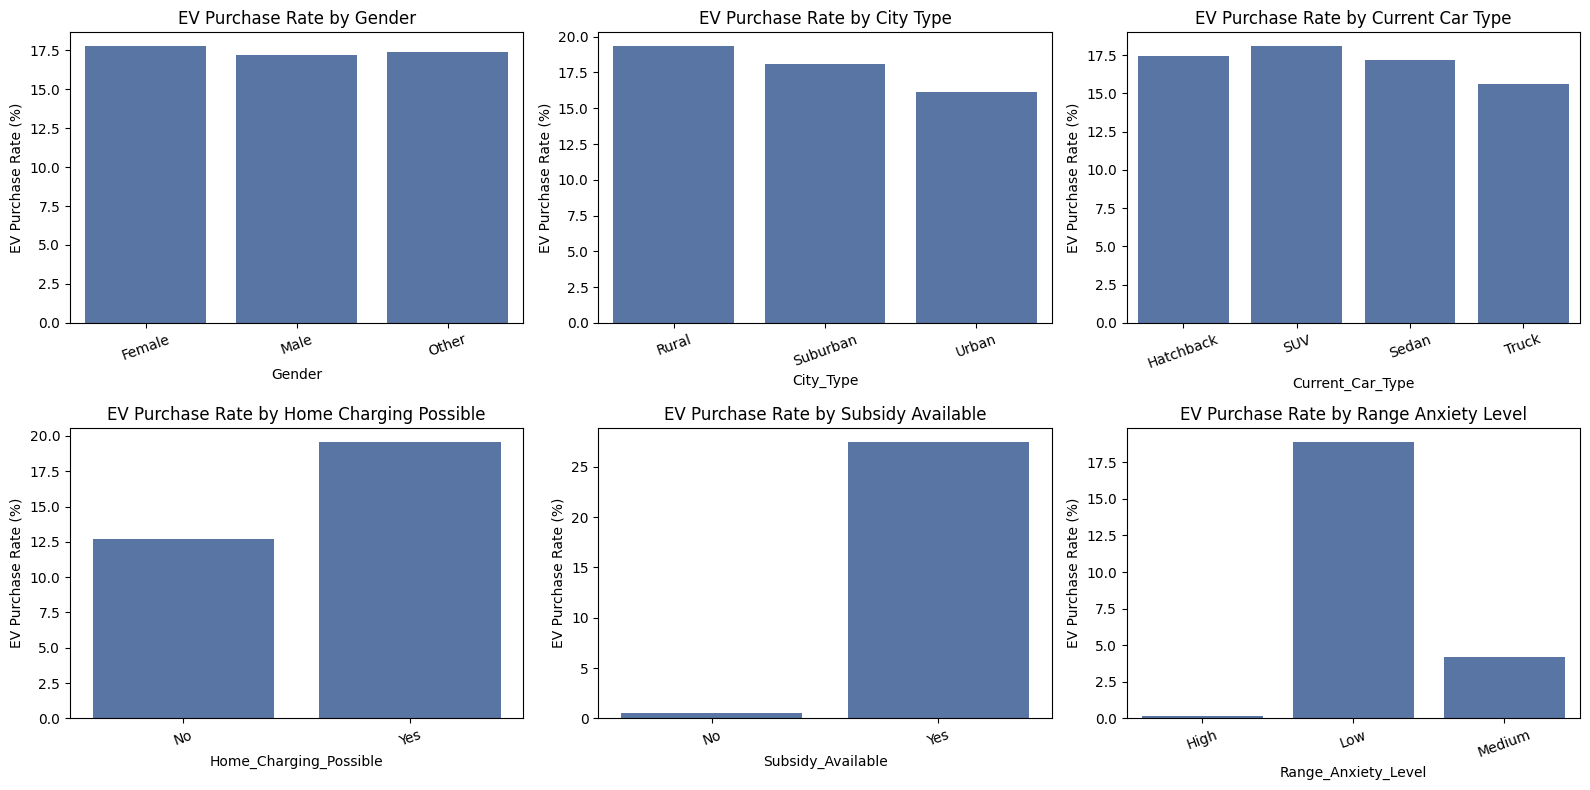

In [20]:
fig , axes = plt.subplots(2 , 3 , figsize=(16,8))
axes = axes.flatten()

eda_train = train.copy()
eda_train["EV_Buyer"] = target_numeric

for ax , col in zip(axes , categorical_cols):
    rates = eda_train.groupby(col)["EV_Buyer"].mean().mul(100).reset_index()
    sns.barplot(data=rates , x=col , y="EV_Buyer" , ax=ax , color=plot_color)
    ax.set_title(f"EV Purchase Rate by {col.replace('_' , ' ')}")
    ax.set_ylabel("EV Purchase Rate (%)")
    ax.tick_params(axis="x" , rotation=20)

plt.tight_layout()
plt.show()

Ohh, this section reveals two extremely strong categorical signals. 🔎

- `Subsidy_Available = Yes` → about **27.47%** EV purchase rate, compared with only **0.58%** when no subsidy is available.
- `Range_Anxiety_Level = Low` → about **18.90%**, Medium drops to **4.17%**, and High is almost zero at roughly **0.14%**.

Home charging also matters: customers who can charge at home reach about **19.58%**, compared with **12.71%** without home charging. City type and current car type show smaller but still visible differences, while gender is almost flat.

## EV Purchase Pattern Analysis

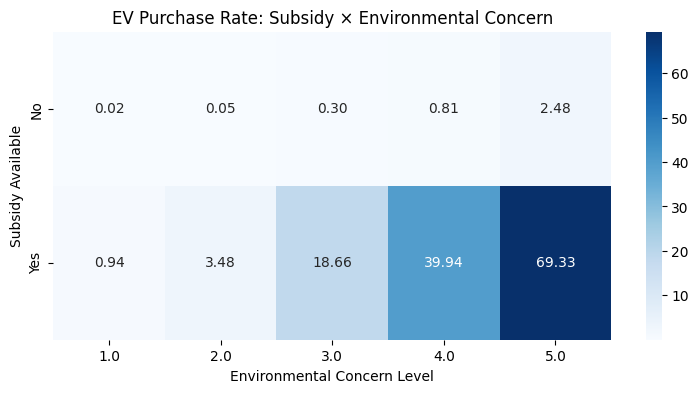

Environmental_Concern_Level,1.0,2.0,3.0,4.0,5.0
Subsidy_Available,,,,,
No,0.02,0.05,0.30,0.81,2.48
Yes,0.94,3.48,18.66,39.94,69.33


In [21]:
subsidy_concern = eda_train.pivot_table(
    index="Subsidy_Available" ,
    columns="Environmental_Concern_Level" ,
    values="EV_Buyer" ,
    aggfunc="mean"
).mul(100).round(2)

plt.figure(figsize=(9,4))
sns.heatmap(subsidy_concern , annot=True , fmt=".2f" , cmap="Blues")
plt.title("EV Purchase Rate: Subsidy × Environmental Concern")
plt.xlabel("Environmental Concern Level")
plt.ylabel("Subsidy Available")
plt.show()

subsidy_concern

This interaction is one of the clearest patterns in the whole dataset. 😮

Without a subsidy, even highly environment-conscious customers have a low purchase rate. But when a subsidy is available, the effect of environmental concern becomes huge — customers at concern Level 5 reach roughly **69.33% EV purchase rate**.

That strongly suggests `Subsidy × Environmental Concern` is a meaningful interaction worth creating in Feature Engineering.

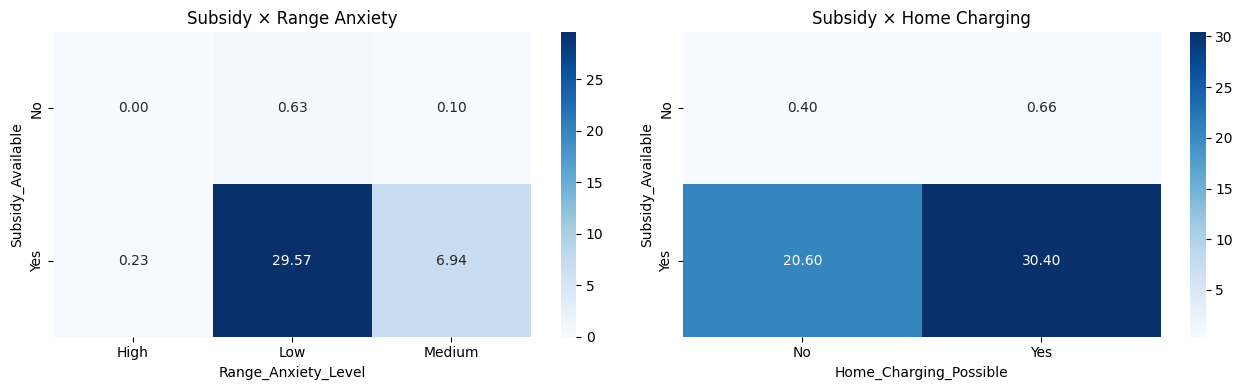

In [22]:
fig , axes = plt.subplots(1 , 2 , figsize=(13,4))

subsidy_range = eda_train.pivot_table(
    index="Subsidy_Available" ,
    columns="Range_Anxiety_Level" ,
    values="EV_Buyer" ,
    aggfunc="mean"
).mul(100)

home_subsidy = eda_train.pivot_table(
    index="Subsidy_Available" ,
    columns="Home_Charging_Possible" ,
    values="EV_Buyer" ,
    aggfunc="mean"
).mul(100)

sns.heatmap(subsidy_range , annot=True , fmt=".2f" , cmap="Blues" , ax=axes[0])
axes[0].set_title("Subsidy × Range Anxiety")

sns.heatmap(home_subsidy , annot=True , fmt=".2f" , cmap="Blues" , ax=axes[1])
axes[1].set_title("Subsidy × Home Charging")

plt.tight_layout()
plt.show()

Yeah, the interaction story continues.

A subsidy helps most when range anxiety is low, but it cannot fully overcome medium or high anxiety. Home charging also strengthens the subsidy effect: with subsidy available, customers who can charge at home purchase EVs at about **30.4%**, compared with about **20.6%** without home charging.

So the next notebook should create only a **small number of domain-supported interactions** instead of blindly multiplying every feature.

## Correlation Analysis

In [23]:
corr_df = train.select_dtypes(include=np.number).copy()
corr_df["EV_Buyer"] = target_numeric

corr_df.corr()["EV_Buyer"].sort_values(ascending=False)

EV_Buyer                       1.000000
Environmental_Concern_Level    0.464079
Annual_Income_USD              0.225729
Number_of_Cars_Owned           0.003896
id                            -0.000013
Age                           -0.007450
Charging_Stations_Near_Work   -0.012229
Charging_Stations_Near_Home   -0.016353
Daily_Commute_km              -0.045866
Name: EV_Buyer, dtype: float64

Ohh, the linear correlations confirm what we already saw.

`Environmental_Concern_Level` has by far the strongest positive numerical relationship with the target at about **+0.46**, followed by `Annual_Income_USD` at about **+0.23**.

Most other raw numerical variables have weak linear correlations. That does **not** mean they are useless — tree models and interaction features can still capture nonlinear effects — but it tells us where the strongest raw signal lives.

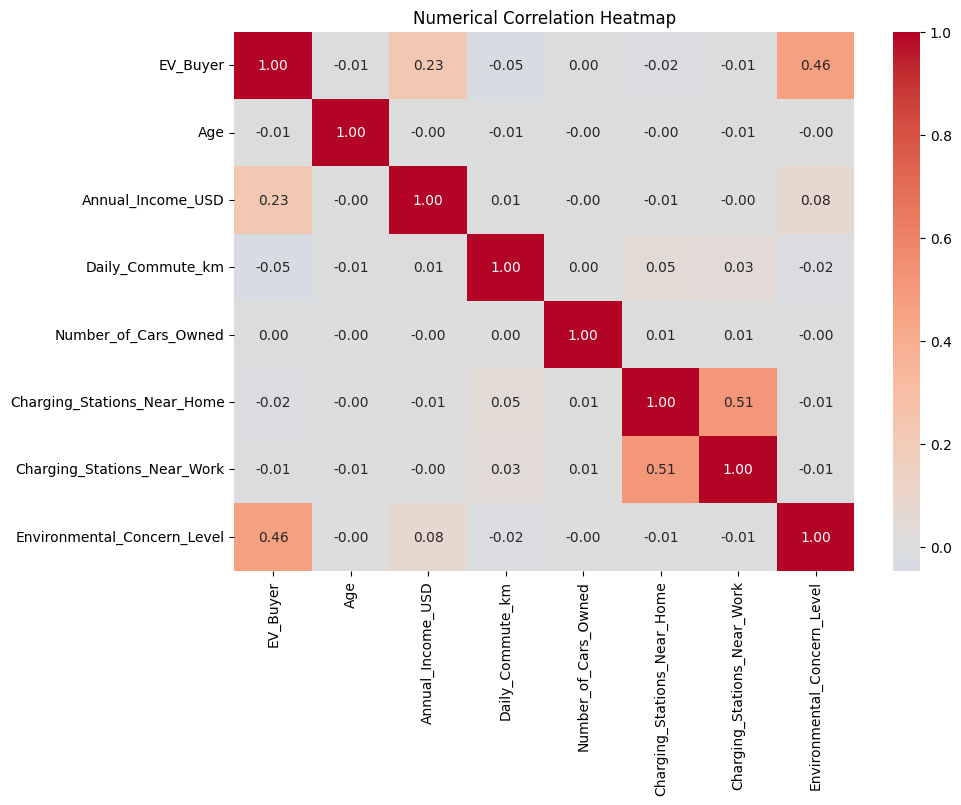

In [24]:
corr_cols = [
    "EV_Buyer" , "Age" , "Annual_Income_USD" , "Daily_Commute_km" ,
    "Number_of_Cars_Owned" , "Charging_Stations_Near_Home" ,
    "Charging_Stations_Near_Work" , "Environmental_Concern_Level"
]

plt.figure(figsize=(10,7))
sns.heatmap(corr_df[corr_cols].corr() , annot=True , fmt=".2f" , cmap="coolwarm" , center=0)
plt.title("Numerical Correlation Heatmap")
plt.show()

The heatmap also shows that our numerical predictors are not heavily correlated with one another.

That is useful because we do not have an obvious multicollinearity problem. The strongest story remains target-specific rather than a group of near-duplicate numeric features.

## Outlier Analysis

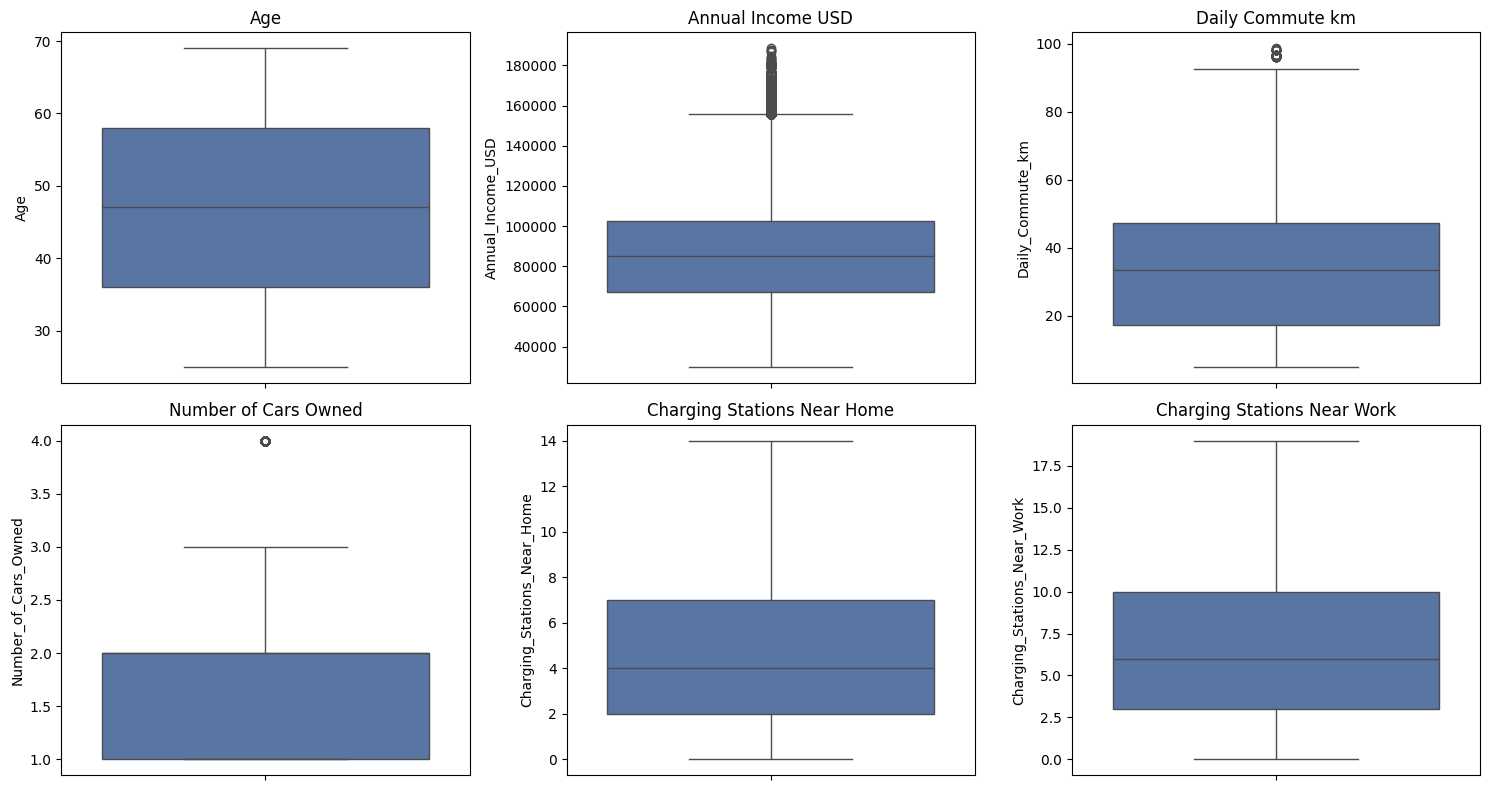

In [25]:
fig , axes = plt.subplots(2 , 3 , figsize=(15,8))
axes = axes.flatten()

outlier_cols = [
    "Age" , "Annual_Income_USD" , "Daily_Commute_km" ,
    "Number_of_Cars_Owned" , "Charging_Stations_Near_Home" , "Charging_Stations_Near_Work"
]

for ax , col in zip(axes , outlier_cols):
    sns.boxplot(data=train , y=col , ax=ax , color=plot_color)
    ax.set_title(col.replace("_" , " "))

plt.tight_layout()
plt.show()

In [26]:
outlier_summary = []

for col in [c for c in numerical_cols if c != "id"]:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((train[col] < lower) | (train[col] > upper)).sum()
    outlier_summary.append([col , count , round(count / len(train) * 100 , 2)])

pd.DataFrame(outlier_summary , columns=["Feature" , "IQR Outliers" , "Percent"]).sort_values("Percent" , ascending=False)

,Feature,IQR Outliers,Percent
3,Number_of_Cars_Owned,13489,2.02
1,Annual_Income_USD,3678,0.55
2,Daily_Commute_km,41,0.01
0,Age,0,0.00
4,Charging_Stations_Near_Home,0,0.00
5,Charging_Stations_Near_Work,0,0.00
6,Environmental_Concern_Level,0,0.00


Hmm, the boxplots show some tail values, but nothing looks like obvious corrupted data.

Using the simple IQR rule, `Number_of_Cars_Owned = 4` is flagged for about **2.02%** of rows, and high annual income values flag about **0.55%**. But four cars and higher income are both perfectly plausible in this context.

So we should **not blindly remove statistical outliers**. Tree-based models can handle these ranges well, and arbitrary trimming could throw away useful high-value customers.

## Train vs Test Distribution

In [27]:
numeric_compare = pd.DataFrame({
    "Train Mean": train[[c for c in numerical_cols if c != "id"]].mean(),
    "Test Mean": test[[c for c in numerical_cols if c != "id"]].mean(),
    "Train Std": train[[c for c in numerical_cols if c != "id"]].std(),
    "Test Std": test[[c for c in numerical_cols if c != "id"]].std()
})

numeric_compare["Mean Difference %"] = (
    (numeric_compare["Test Mean"] - numeric_compare["Train Mean"]) /
    numeric_compare["Train Mean"] * 100
).round(3)

numeric_compare.round(3)

,Train Mean,Test Mean,Train Std,Test Std,Mean Difference %
Age,47.039,47.071,12.875,12.865,0.067
Annual_Income_USD,84769.267,84799.508,28648.029,28626.851,0.036
Daily_Commute_km,32.158,32.159,18.730,18.724,0.003
Number_of_Cars_Owned,1.713,1.716,0.729,0.731,0.203
Charging_Stations_Near_Home,4.960,4.951,3.927,3.929,-0.196
Charging_Stations_Near_Work,7.176,7.156,5.187,5.187,-0.288
Environmental_Concern_Level,2.935,2.935,1.429,1.428,-0.031


In [28]:
category_shift = []

for col in categorical_cols:
    train_prop = train[col].value_counts(normalize=True)
    test_prop = test[col].value_counts(normalize=True)
    all_categories = train_prop.index.union(test_prop.index)
    max_diff = (train_prop.reindex(all_categories , fill_value=0) - test_prop.reindex(all_categories , fill_value=0)).abs().max()
    category_shift.append([col , round(max_diff * 100 , 3)])

pd.DataFrame(category_shift , columns=["Feature" , "Max Proportion Difference (%)"])

,Feature,Max Proportion Difference (%)
0,Gender,0.020
1,City_Type,0.135
2,Current_Car_Type,0.075
3,Home_Charging_Possible,0.066
4,Subsidy_Available,0.145
5,Range_Anxiety_Level,0.171


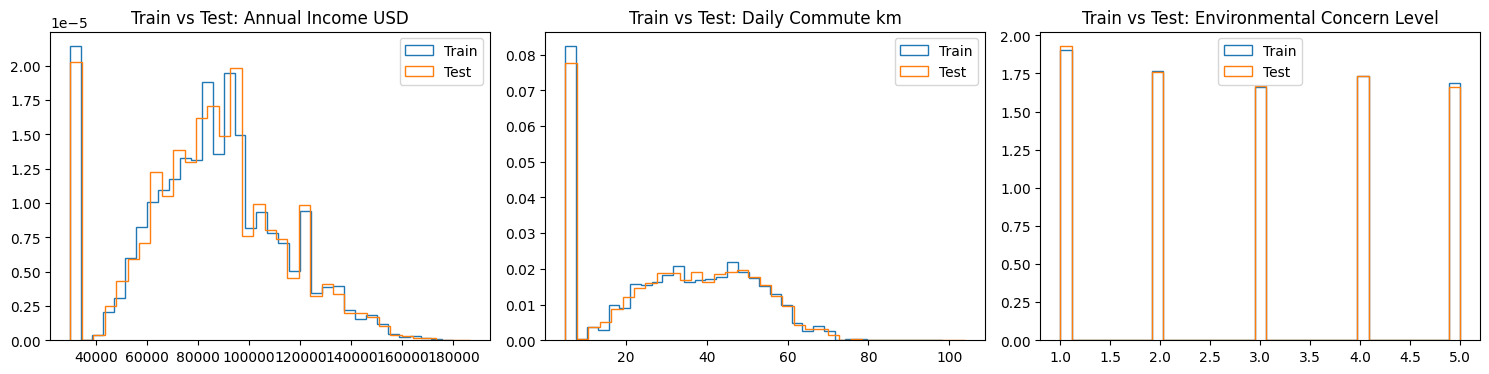

In [29]:
train_plot = train.sample(n=50000 , random_state=42)
test_plot = test.sample(n=50000 , random_state=42)

fig , axes = plt.subplots(1 , 3 , figsize=(15,4))

for ax , col in zip(axes , ["Annual_Income_USD" , "Daily_Commute_km" , "Environmental_Concern_Level"]):
    ax.hist(train_plot[col] , bins=35 , density=True , histtype="step" , label="Train")
    ax.hist(test_plot[col] , bins=35 , density=True , histtype="step" , label="Test")
    ax.set_title(f"Train vs Test: {col.replace('_' , ' ')}")
    ax.legend()

plt.tight_layout()
plt.show()

Nice — train and Kaggle test are extremely well aligned. ✅

The numerical means and standard deviations are almost identical, and the largest categorical proportion differences are only around a few **tenths of one percentage point**.

The visual overlays tell the same story. We do not see an obvious train/test distribution shift, so standard validation should be reasonably representative of the hidden Kaggle test set.

## ID and Leakage Check

In [30]:
id_check = train.assign(EV_Buyer=target_numeric)
id_check["ID_Decile"] = pd.qcut(id_check["id"] , q=10)

id_target_rate = id_check.groupby("ID_Decile" , observed=False)["EV_Buyer"].mean().mul(100).round(2)

print("Correlation between id and target:", round(train["id"].corr(target_numeric) , 6))
id_target_rate

Correlation between id and target: -1.3e-05


ID_Decile
(-0.001, 66866.4]       17.47
(66866.4, 133732.8]     17.47
(133732.8, 200599.2]    17.45
(200599.2, 267465.6]    17.43
(267465.6, 334332.0]    17.54
(334332.0, 401198.4]    17.56
(401198.4, 468064.8]    17.51
(468064.8, 534931.2]    17.14
(534931.2, 601797.6]    17.57
(601797.6, 668664.0]    17.53
Name: EV_Buyer, dtype: float64

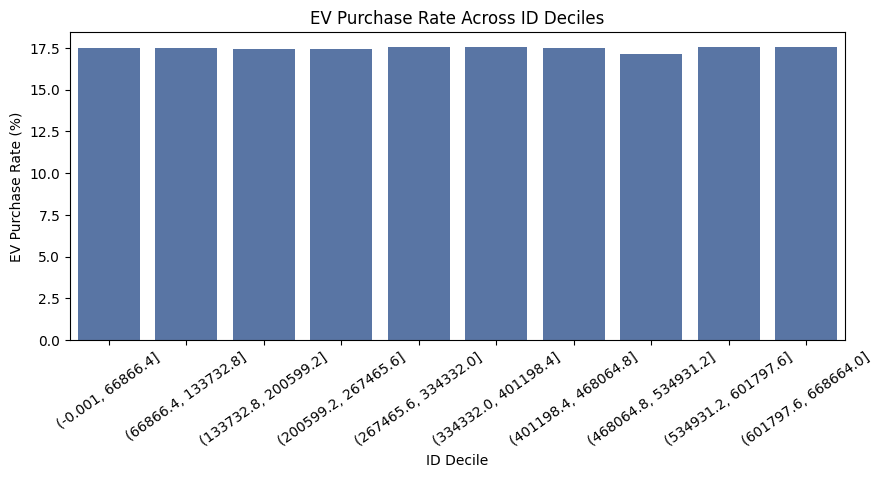

In [31]:
plt.figure(figsize=(10,4))
sns.barplot(x=id_target_rate.index.astype(str) , y=id_target_rate.values , color=plot_color)
plt.title("EV Purchase Rate Across ID Deciles")
plt.xlabel("ID Decile")
plt.ylabel("EV Purchase Rate (%)")
plt.xticks(rotation=35)
plt.show()

Good — `id` behaves like a pure row identifier.

Its correlation with the target is essentially **zero**, and EV purchase rate stays almost flat across ID deciles. We also do not have any post-outcome columns that directly reveal `Will_Buy_EV`.

So there is no obvious target leakage in the supplied predictors, but `id` should still be **excluded from modeling** and kept only for Kaggle submission alignment.

## EDA Findings

In [32]:
eda_summary = pd.Series({
    "Train Rows": train.shape[0],
    "Test Rows": test.shape[0],
    "Training Columns": train.shape[1],
    "Missing Values": int(train.isnull().sum().sum()),
    "Duplicate Rows": int(train.duplicated().sum()),
    "EV Buyer Rate (%)": round((train["Will_Buy_EV"] == "Yes").mean() * 100 , 2),
    "Numerical Predictors": len([c for c in numerical_cols if c != "id"]),
    "Categorical Predictors": len(categorical_cols)
})

eda_summary

Train Rows                668665.00
Test Rows                 286571.00
Training Columns              15.00
Missing Values                 0.00
Duplicate Rows                 0.00
EV Buyer Rate (%)             17.46
Numerical Predictors           7.00
Categorical Predictors         6.00
dtype: float64

Okay, we now have a clear roadmap for Feature Engineering. 🚀

| EDA Finding | Next Action |
|---|---|
| No missing values | No imputation needed |
| No duplicate rows | No duplicate removal needed |
| `id` has no predictive pattern | Keep only for submission, drop from model features |
| Positive class is only **17.46%** | Use stratification and prioritize ROC-AUC |
| Income has a strong positive relationship | Preserve it and consider simple affordability interactions |
| Environmental concern is one of the strongest raw signals | Preserve its ordered structure |
| Subsidy availability creates a very large purchase-rate gap | Keep as a key binary feature |
| Range anxiety has a very strong ordered effect | Encode it as an ordinal feature rather than arbitrary labels |
| Home charging improves EV purchase rate | Keep and test infrastructure interactions |
| `Subsidy × Concern` is extremely strong | Create a small, meaningful interaction feature |
| Train and test distributions are closely aligned | Standard validation should be reliable |
| Statistical outliers mostly look plausible | Avoid blind outlier deletion |

That completes the EDA. The next notebook can now focus on **clean, justified feature engineering** instead of guessing which transformations might help.